In [ ]:
from transformers import AutoTokenizer, EsmForMaskedLM
import torch
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_name = "facebook/esm2_t33_650M_UR50D"  # change model according to need, now ESM2 650M parameter model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmForMaskedLM.from_pretrained(model_name).to(device)
model.eval()

def generate_heatmap_and_embeddings(protein_sequence, protein_name, start_pos=1, end_pos=None, save_dir="embeddings", show_plot=True):
    """
    Calculate LLRs for each mutant/wildtype residue using chosen model and produce heatmap
    """
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)


    # Tokenize the input sequence
    input_ids = tokenizer.encode(protein_sequence, return_tensors="pt").to(device)
    sequence_length = input_ids.shape[1] - 2  # Excluding the special tokens

    # Adjust end position if not specified
    if end_pos is None:
        end_pos = sequence_length

    # List of amino acids
    amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

    # Initialize heatmap
    heatmap = np.zeros((20, end_pos - start_pos + 1))

    # Calculate LLRs for each position and amino acid
    for position in range(start_pos, end_pos + 1):
        # Mask the target position
        masked_input_ids = input_ids.clone().to(device)
        masked_input_ids[0, position] = tokenizer.mask_token_id

        # Get logits for the masked token
        with torch.no_grad():
            logits = model(masked_input_ids).logits

        # Calculate log probabilities
        probabilities = torch.nn.functional.softmax(logits[0, position], dim=0)
        log_probabilities = torch.log(probabilities)

        # Get the log probability of the wild-type residue
        wt_residue = input_ids[0, position].item()
        log_prob_wt = log_probabilities[wt_residue].item()

        # Calculate LLR for each variant
        for i, amino_acid in enumerate(amino_acids):
            log_prob_mt = log_probabilities[tokenizer.convert_tokens_to_ids(amino_acid)].item()
            heatmap[i, position - start_pos] = log_prob_mt - log_prob_wt


        # Create DataFrame for the heatmap
    position_labels = [f"pos_{i}" for i in range(start_pos, end_pos + 1)]
    wt_sequence = list(protein_sequence[start_pos-1:end_pos])

    # Create the DataFrame
    df_heatmap = pd.DataFrame(
        heatmap.T,  # Transpose so positions are rows and amino acids are columns
        columns=amino_acids,
        index=position_labels
    )

    # Add wild-type sequence as a column for reference
    df_heatmap.insert(0, 'WT_residue', wt_sequence)
    df_heatmap.insert(1, 'position', range(start_pos, end_pos + 1))

    # Save the heatmap data
    heatmap_file = f"{save_dir}/{protein_name}_LLR_heatmap.csv"
    df_heatmap.to_csv(heatmap_file, index=True)
    print(f"LLR heatmap saved to: {heatmap_file}")

    if show_plot:
        plt.figure(figsize=((len(protein_sequence) * 0.2), 5))
        plt.imshow(heatmap, cmap="viridis", aspect="auto")
        plt.xticks(range(end_pos - start_pos + 1), list(protein_sequence[start_pos-1:end_pos]))
        plt.yticks(range(20), amino_acids)
        plt.xlabel("Position in Protein Sequence")
        plt.ylabel("Amino Acid Mutations")
        plt.title(f"Predicted Effects of Mutations - {protein_name}")  # Fixed: protein_name not proteins_name
        plt.colorbar(label="Log Likelihood Ratio (LLR)")
        plt.show()

    return df_heatmap, heatmap



Using device: cuda:0


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Now processing EspB
LLR heatmap saved to: embeddings/EspB_LLR_heatmap.csv


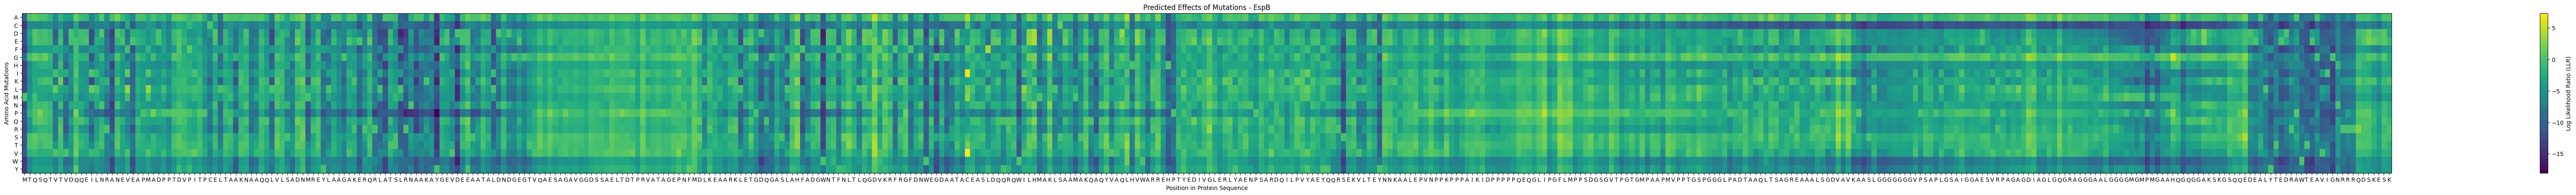

Now processing EspK
LLR heatmap saved to: embeddings/EspK_LLR_heatmap.csv


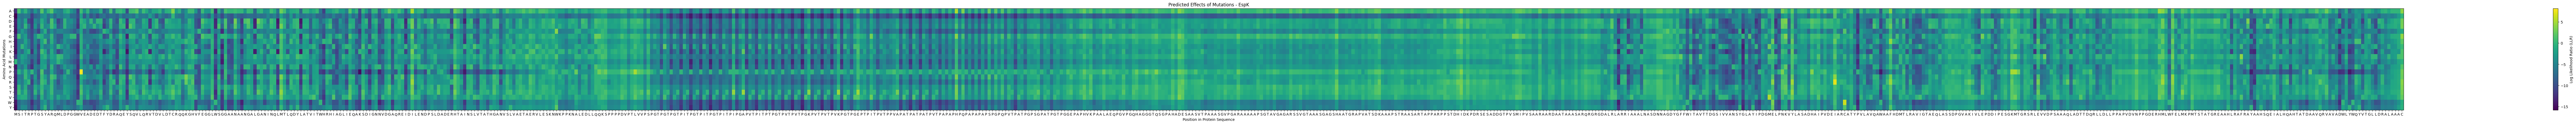

Now processing EspJ
LLR heatmap saved to: embeddings/EspJ_LLR_heatmap.csv


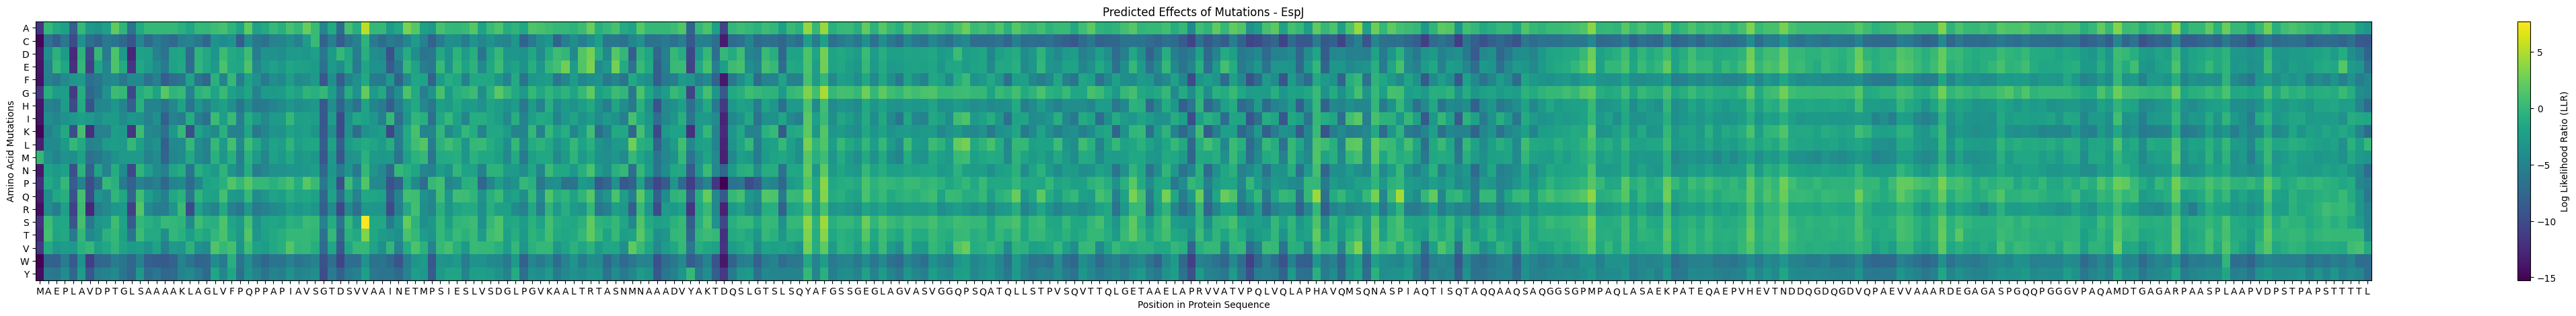

Now processing EspI
LLR heatmap saved to: embeddings/EspI_LLR_heatmap.csv


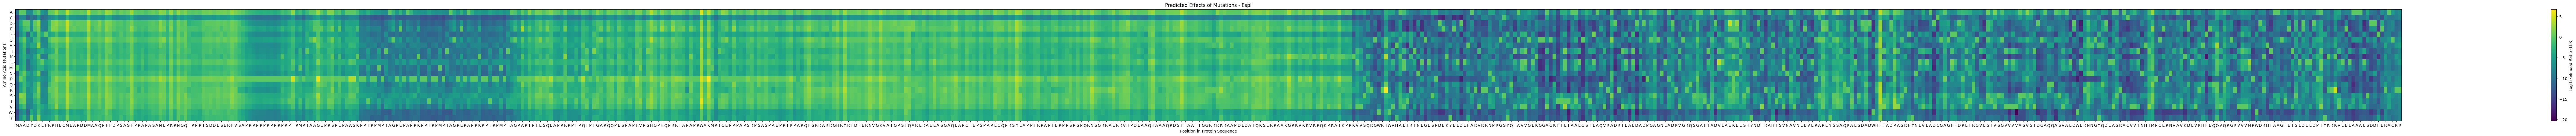

Now processing PPE68
LLR heatmap saved to: embeddings/PPE68_LLR_heatmap.csv


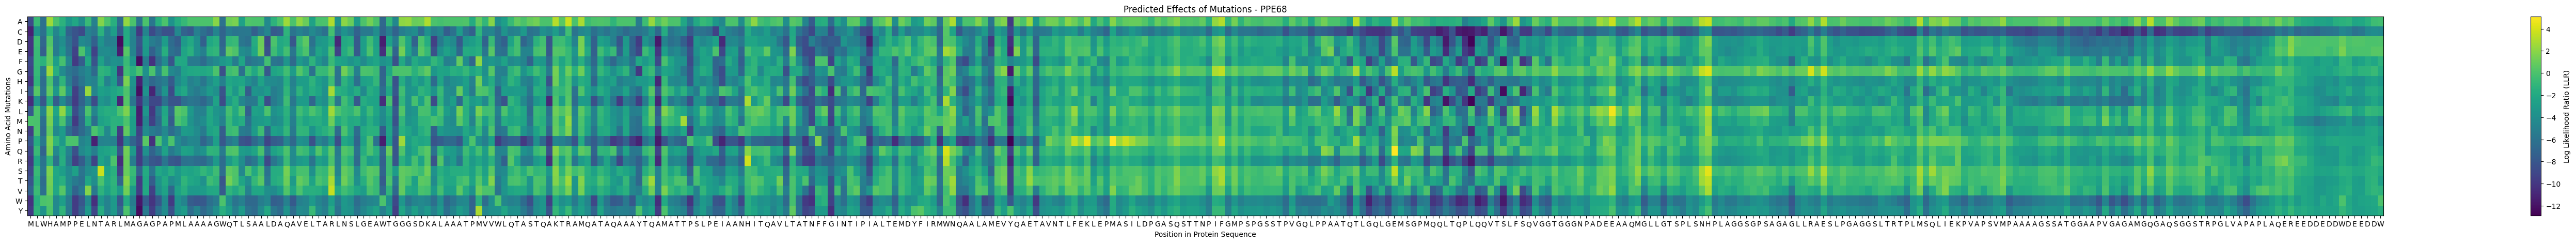

Now processing EspH
LLR heatmap saved to: embeddings/EspH_LLR_heatmap.csv


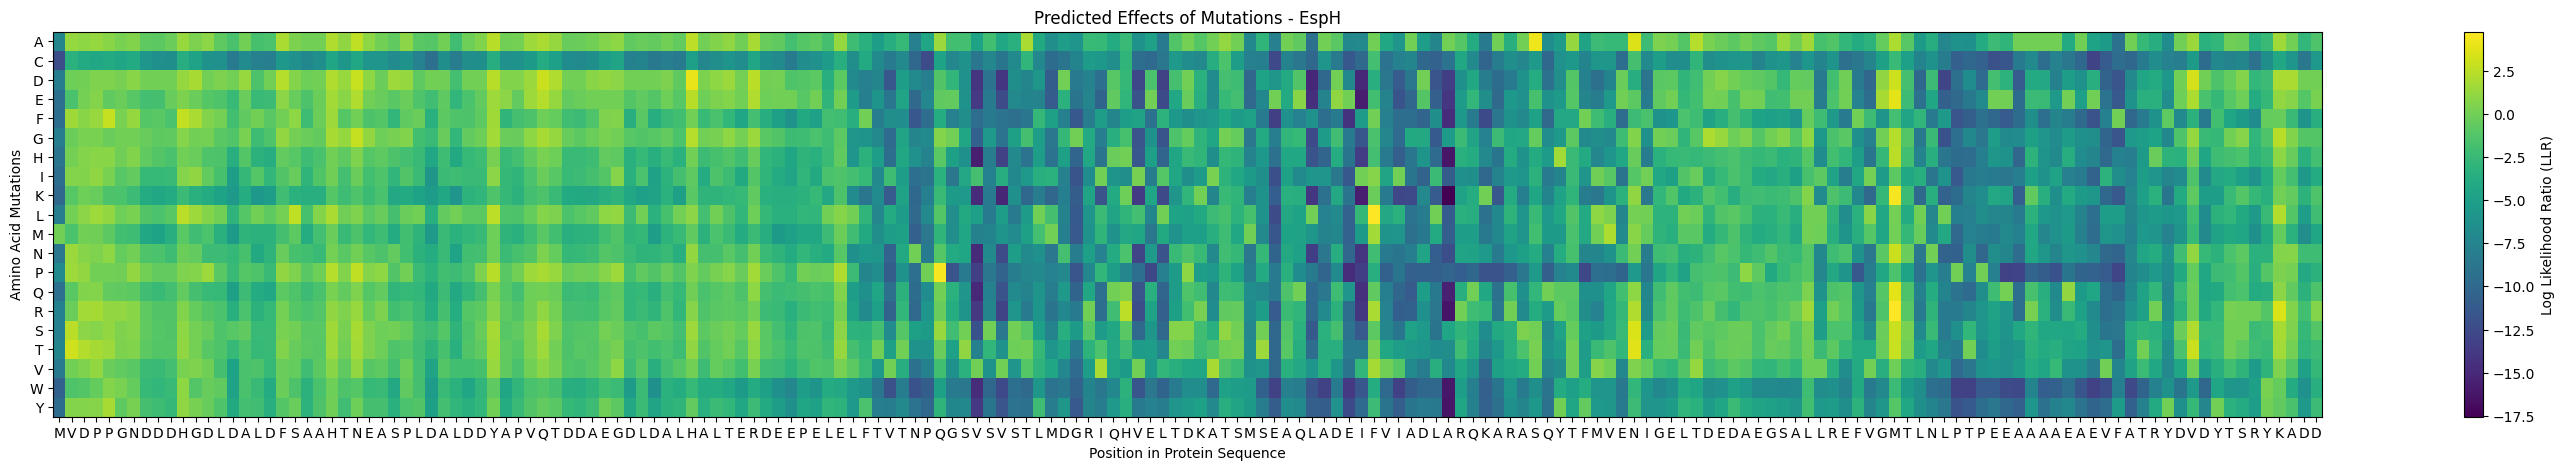

Now processing EspE
LLR heatmap saved to: embeddings/EspE_LLR_heatmap.csv


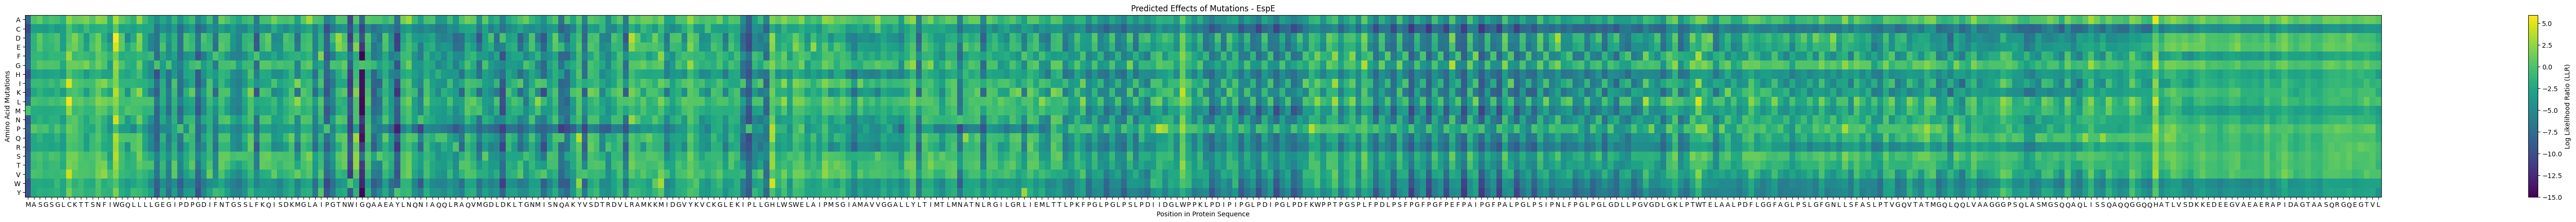

Now processing EspM
LLR heatmap saved to: embeddings/EspM_LLR_heatmap.csv


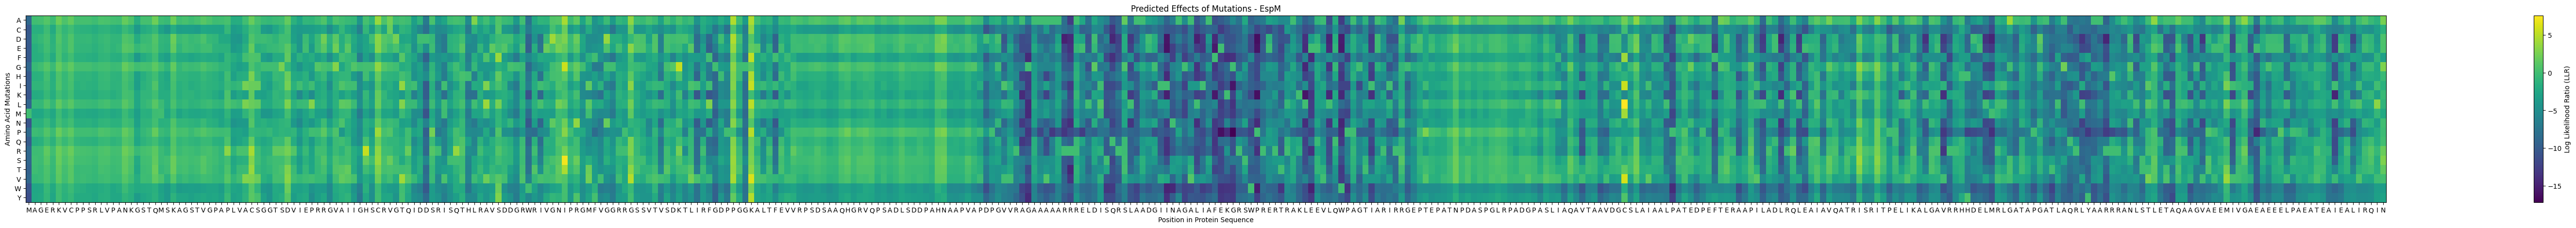

Now processing EspA
LLR heatmap saved to: embeddings/EspA_LLR_heatmap.csv


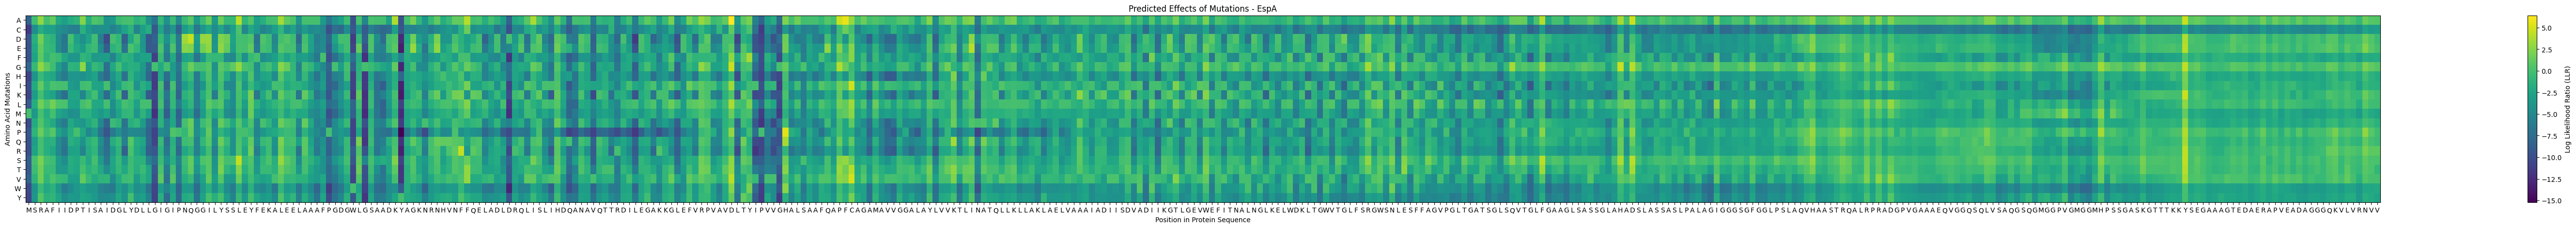

Now processing EspD
LLR heatmap saved to: embeddings/EspD_LLR_heatmap.csv


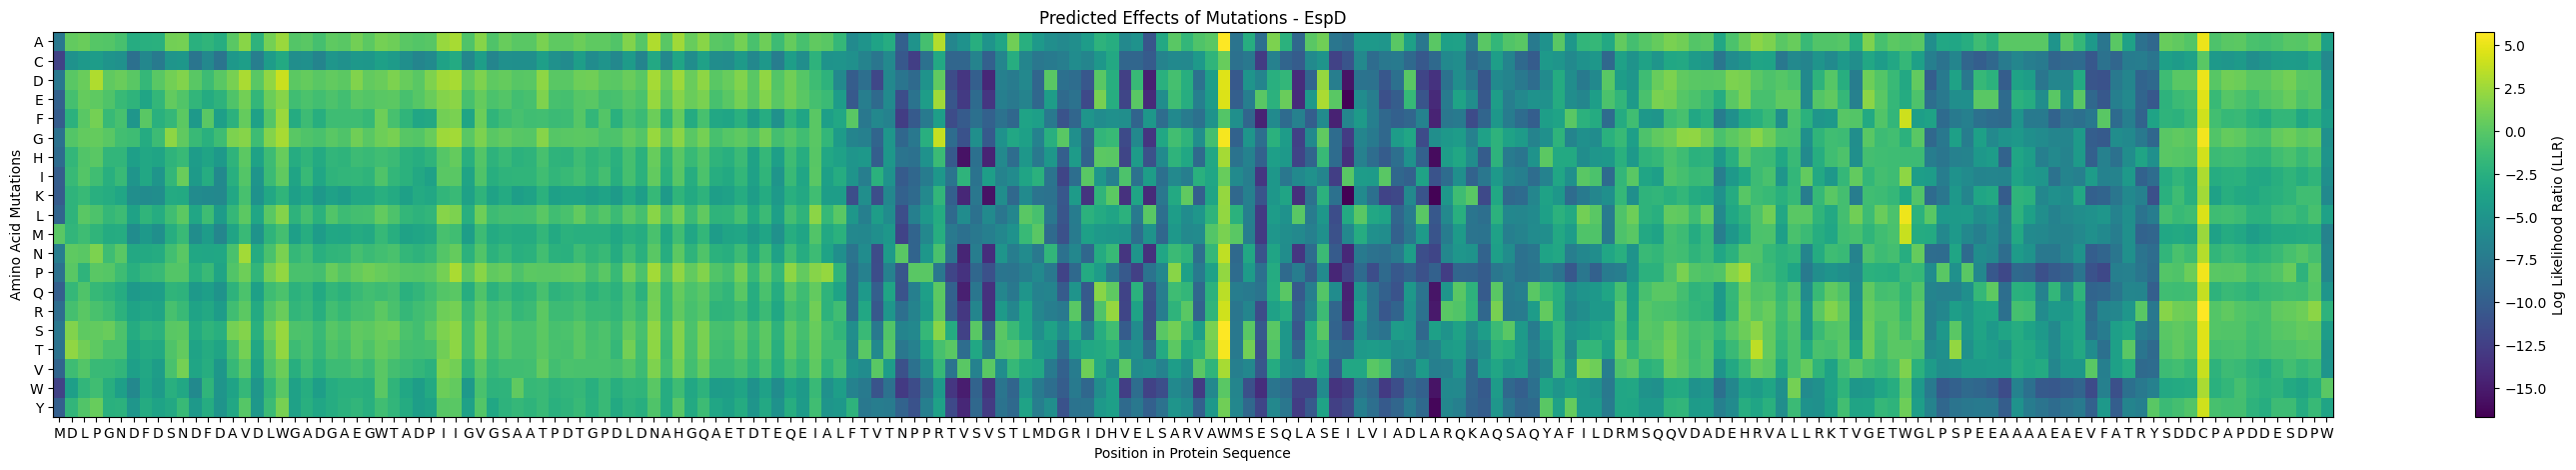

Now processing Lsr2
LLR heatmap saved to: embeddings/Lsr2_LLR_heatmap.csv


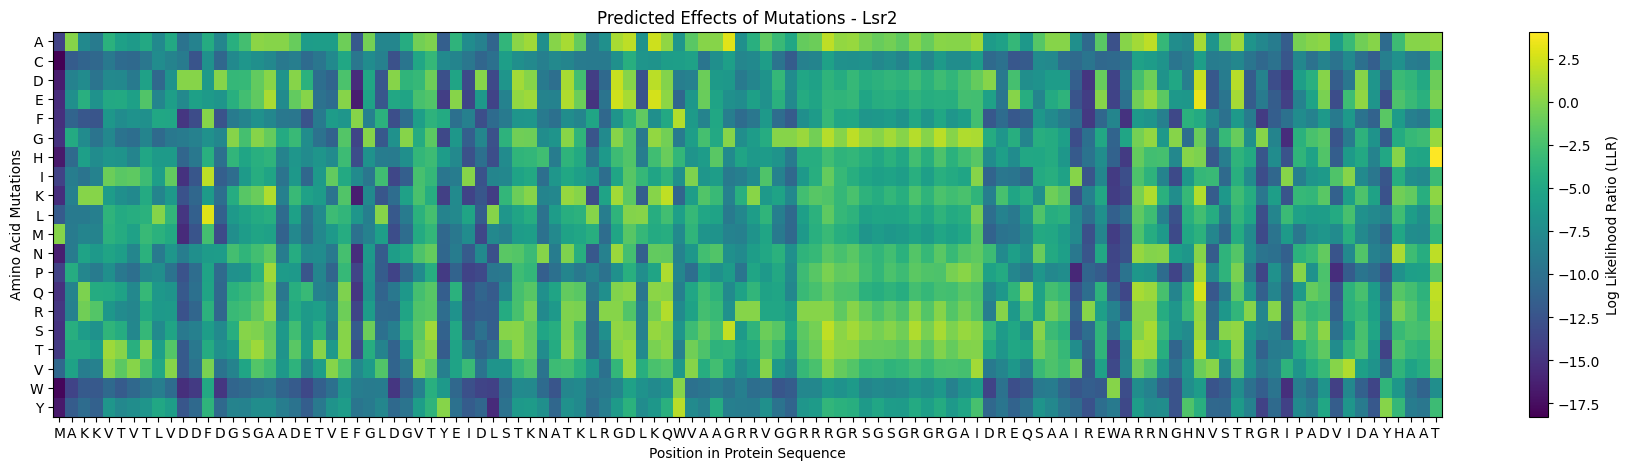

In [3]:
# Example usage:
rel_prot = {"EspB": "MTQSQTVTVDQQEILNRANEVEAPMADPPTDVPITPCELTAAKNAAQQLVLSADNMREYLAAGAKERQRLATSLRNAAKAYGEVDEEAATALDNDGEGTVQAESAGAVGGDSSAELTDTPRVATAGEPNFMDLKEAARKLETGDQGASLAHFADGWNTFNLTLQGDVKRFRGFDNWEGDAATACEASLDQQRQWILHMAKLSAAMAKQAQYVAQLHVWARREHPTYEDIVGLERLYAENPSARDQILPVYAEYQQRSEKVLTEYNNKAALEPVNPPKPPPAIKIDPPPPPQEQGLIPGFLMPPSDGSGVTPGTGMPAAPMVPPTGSPGGGLPADTAAQLTSAGREAAALSGDVAVKAASLGGGGGGGVPSAPLGSAIGGAESVRPAGAGDIAGLGQGRAGGGAALGGGGMGMPMGAAHQGQGGAKSKGSQQEDEALYTEDRAWTEAVIGNRRRQDSKESK",
            "EspK": "MSITRPTGSYARQMLDPGGWVEADEDTFYDRAQEYSQVLQRVTDVLDTCRQQKGHVFEGGLWSGGAANAANGALGANINQLMTLQDYLATVITWHRHIAGLIEQAKSDIGNNVDGAQREIDILENDPSLDADERHTAINSLVTATHGANVSLVAETAERVLESKNWKPPKNALEDLLQQKSPPPPDVPTLVVPSPGTPGTPGTPITPGTPITPGTPITPIPGAPVTPITPTPGTPVTPVTPGKPVTPVTPVKPGTPGEPTPITPVTPPVAPATPATPATPVTPAPAPHPQPAPAPAPSPGPQPVTPATPGPSGPATPGTPGGEPAPHVKPAALAEQPGVPGQHAGGGTQSGPAHADESAASVTPAAASGVPGARAAAAAPSGTAVGAGARSSVGTAAASGAGSHAATGRAPVATSDKAAAPSTRAASARTAPPARPPSTDHIDKPDRSESADDGTPVSMIPVSAARAARDAATAAASARQRGRGDALRLARRIAAALNASDNNAGDYGFFWITAVTTDGSIVVANSYGLAYIPDGMELPNKVYLASADHAIPVDEIARCATYPVLAVQAWAAFHDMTLRAVIGTAEQLASSDPGVAKIVLEPDDIPESGKMTGRSRLEVVDPSAAAQLADTTDQRLLDLLPPAPVDVNPPGDERHMLWFELMKPMTSTATGREAAHLRAFRAYAAHSQEIALHQAHTATDAAVQRVAVADWLYWQYVTGLLDRALAAAC",
            "EspJ": "MAEPLAVDPTGLSAAAAKLAGLVFPQPPAPIAVSGTDSVVAAINETMPSIESLVSDGLPGVKAALTRTASNMNAAADVYAKTDQSLGTSLSQYAFGSSGEGLAGVASVGGQPSQATQLLSTPVSQVTTQLGETAAELAPRVVATVPQLVQLAPHAVQMSQNASPIAQTISQTAQQAAQSAQGGSGPMPAQLASAEKPATEQAEPVHEVTNDDQGDQGDVQPAEVVAAARDEGAGASPGQQPGGGVPAQAMDTGAGARPAASPLAAPVDPSTPAPSTTTTL",
            "EspI": "MAADYDKLFRPHEGMEAPDDMAAQPFFDPSASFPPAPASANLPKPNGQTPPPTSDDLSERFVSAPPPPPPPPPPPPPTPMPIAAGEPPSPEPAASKPPTPPMPIAGPEPAPPKPPTPPMPIAGPEPAPPKPPTPPMPIAGPAPTPTESQLAPPRPPTPQTPTGAPQQPESPAPHVPSHGPHQPRRTAPAPPWAKMPIGEPPPAPSRPSASPAEPPTRPAPQHSRRARRGHRYRTDTERNVGKVATGPSIQARLRAEEASGAQLAPGTEPSPAPLGQPRSYLAPPTRPAPTEPPPSPSPQRNSGRRAERRVHPDLAAQHAAAQPDSITAATTGGRRRKRAAPDLDATQKSLRPAAKGPKVKKVKPQKPKATKPPKVVSQRGWRHWVHALTRINLGLSPDEKYELDLHARVRRNPRGSYQIAVVGLKGGAGKTTLTAALGSTLAQVRADRILALDADPGAGNLADRVGRQSGATIADVLAEKELSHYNDIRAHTSVNAVNLEVLPAPEYSSAQRALSDADWHFIADPASRFYNLVLADCGAGFFDPLTRGVLSTVSGVVVVASVSIDGAQQASVALDWLRNNGYQDLASRACVVINHIMPGEPNVAVKDLVRHFEQQVQPGRVVVMPWDRHIAAGTEISLDLLDPIYKRKVLELAAALSDDFERAGRR",
            "PPE68": "MLWHAMPPELNTARLMAGAGPAPMLAAAAGWQTLSAALDAQAVELTARLNSLGEAWTGGGSDKALAAATPMVVWLQTASTQAKTRAMQATAQAAAYTQAMATTPSLPEIAANHITQAVLTATNFFGINTIPIALTEMDYFIRMWNQAALAMEVYQAETAVNTLFEKLEPMASILDPGASQSTTNPIFGMPSPGSSTPVGQLPPAATQTLGQLGEMSGPMQQLTQPLQQVTSLFSQVGGTGGGNPADEEAAQMGLLGTSPLSNHPLAGGSGPSAGAGLLRAESLPGAGGSLTRTPLMSQLIEKPVAPSVMPAAAAGSSATGGAAPVGAGAMGQGAQSGGSTRPGLVAPAPLAQEREEDDEDDWDEEDDW",
            "EspH": "MVDPPGNDDDHGDLDALDFSAAHTNEASPLDALDDYAPVQTDDAEGDLDALHALTERDEEPELELFTVTNPQGSVSVSTLMDGRIQHVELTDKATSMSEAQLADEIFVIADLARQKARASQYTFMVENIGELTDEDAEGSALLREFVGMTLNLPTPEEAAAAEAEVFATRYDVDYTSRYKADD",
            "EspE": "MASGSGLCKTTSNFIWGQLLLLGEGIPDPGDIFNTGSSLFKQISDKMGLAIPGTNWIGQAAEAYLNQNIAQQLRAQVMGDLDKLTGNMISNQAKYVSDTRDVLRAMKKMIDGVYKVCKGLEKIPLLGHLWSWELAIPMSGIAMAVVGGALLYLTIMTLMNATNLRGILGRLIEMLTTLPKFPGLPGLPSLPDIIDGLWPPKLPDIPIPGLPDIPGLPDFKWPPTPGSPLFPDLPSFPGFPGFPEFPAIPGFPALPGLPSIPNLFPGLPGLGDLLPGVGDLGKLPTWTELAALPDFLGGFAGLPSLGFGNLLSFASLPTVGQVTATMGQLQQLVAAGGGPSQLASMGSQQAQLISSQAQQGGQQHATLVSDKKEDEEGVAEAERAPIDAGTAASQRGQEGTVL",
            "EspM": "MAGERKVCPPSRLVPANKGSTQMSKAGSTVGPAPLVACSGGTSDVIEPRRGVAIIGHSCRVGTQIDDSRISQTHLRAVSDDGRWRIVGNIPRGMFVGGRRGSSVTVSDKTLIRFGDPPGGKALTFEVVRPSDSAAQHGRVQPSADLSDDPAHNAAPVAPDPGVVRAGAAAAARRRELDISQRSLAADGIINAGALIAFEKGRSWPRERTRAKLEEVLQWPAGTIARIRRGEPTEPATNPDASPGLRPADGPASLIAQAVTAAVDGCSLAIAALPATEDPEFTERAAPILADLRQLEAIAVQATRISRITPELIKALGAVRRHHDELMRLGATAPGATLAQRLYAARRRANLSTLETAQAAGVAEEMIVGAEAEEELPAEATEAIEALIRQIN",
            "EspA": "MSRAFIIDPTISAIDGLYDLLGIGIPNQGGILYSSLEYFEKALEELAAAFPGDGWLGSAADKYAGKNRNHVNFFQELADLDRQLISLIHDQANAVQTTRDILEGAKKGLEFVRPVAVDLTYIPVVGHALSAAFQAPFCAGAMAVVGGALAYLVVKTLINATQLLKLLAKLAELVAAAIADIISDVADIIKGTLGEVWEFITNALNGLKELWDKLTGWVTGLFSRGWSNLESFFAGVPGLTGATSGLSQVTGLFGAAGLSASSGLAHADSLASSASLPALAGIGGGSGFGGLPSLAQVHAASTRQALRPRADGPVGAAAEQVGGQSQLVSAQGSQGMGGPVGMGGMHPSSGASKGTTTKKYSEGAAAGTEDAERAPVEADAGGGQKVLVRNVV",
            "EspD": "MDLPGNDFDSNDFDAVDLWGADGAEGWTADPIIGVGSAATPDTGPDLDNAHGQAETDTEQEIALFTVTNPPRTVSVSTLMDGRIDHVELSARVAWMSESQLASEILVIADLARQKAQSAQYAFILDRMSQQVDADEHRVALLRKTVGETWGLPSPEEAAAAEAEVFATRYSDDCPAPDDESDPW",
            "Lsr2": "MAKKVTVTLVDDFDGSGAADETVEFGLDGVTYEIDLSTKNATKLRGDLKQWVAAGRRVGGRRRGRSGSGRGRGAIDREQSAAIREWARRNGHNVSTRGRIPADVIDAYHAAT"
           }
for protein, sequence in rel_prot.items():
    print(f"Now processing {protein}")
    generate_heatmap_and_embeddings(sequence, protein, show_plot=True)
